# π⁰ DVCS Production Run Analysis: Data vs Simulation
## HMS Electron Side Diagnostic Plots with HMS Electron Selection Cuts

This notebook compares experimental data from run 4398 with GEANT4/SIMC simulation for π⁰ DVCS exclusive photoproduction. The analysis applies strict HMS electron selection cuts and generates overlay plots for key kinematic variables.

**Data Files:**
- Data: `/group/nps/singhav/nps_replay/rootfiles_avnish/root_analysis_env_skim/x60_4b/skim_run4398.root`
- Simulation: `/w/hallc-scshelf2102/nps/singhav/geant4_simc/HallC_NPS/DVCS_evt_gen/DVCS/nps_excl_pi0_x60_4b_geant_500k.root`

**Analysis Goal:** Validate simulation acceptances and detector response against real data using HMS kinematics

In [104]:
# Section 1: Setup and Configuration
# Import required libraries
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Configure plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 10

# File paths
DATA_FILE = "/w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env/output/plots/x60_4b/combined_branches_LH2.root"
# DATA_FILE = "/w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env/output/plots/x60_4b/production_wfpi0/combined_branches_LH2_wfpi0.root"
SIM_FILE = "/w/hallc-scshelf2102/nps/singhav/geant4_simc/HallC_NPS/DVCS_evt_gen/DVCS/nps_excl_x60_4b_500k.root"

# Output directories
output_dir = "./production_diagnostics"
os.makedirs(output_dir, exist_ok=True)

print("✓ Configuration complete")
print(f"  Data file: {DATA_FILE}")
print(f"  Sim file:  {SIM_FILE}")
print(f"  Output directory: {output_dir}")

✓ Configuration complete
  Data file: /w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env/output/plots/x60_4b/combined_branches_LH2.root
  Sim file:  /w/hallc-scshelf2102/nps/singhav/geant4_simc/HallC_NPS/DVCS_evt_gen/DVCS/nps_excl_x60_4b_500k.root
  Output directory: ./production_diagnostics


In [105]:
# Section 2: Define Analysis Variables
# Kinematic variables to analyze: (data_branch, sim_branch, plot_range)
variables = {
    "HMS δ (%)": ("delta", "hsdelta", (-15, 15)),
    "HMS xptar (rad)": ("xptar", "hsxptar", (-0.1, 0.1)),
    "HMS yptar (rad)": ("yptar", "hsyptar", (-0.05, 0.05)),
    "HMS ytar (cm)": ("ytar", "hsytar", (-4.0, 4.0)),
    "HMS xfp (cm)": ("xfp", "hsxfp", (-50, 50)),
    "HMS yfp (cm)": ("yfp", "hsyfp", (-30, 30)),
    "HMS xpfp (rad)": ("xpfp", "hsxpfp", (-0.08, 0.08)),
    "HMS ypfp (rad)": ("ypfp", "hsypfp", (-0.04, 0.04)),
    "HMS react z (cm)": ("reactz", "hreactz", (-10.0, 10.0)),
}

print("\n✓ Analysis variables defined:")
for var_name, (data_br, sim_br, x_range) in variables.items():
    print(f"  {var_name:20s} → Data: {data_br:15s}, Sim: {sim_br:15s}, Range: {x_range}")


✓ Analysis variables defined:
  HMS δ (%)            → Data: delta          , Sim: hsdelta        , Range: (-15, 15)
  HMS xptar (rad)      → Data: xptar          , Sim: hsxptar        , Range: (-0.1, 0.1)
  HMS yptar (rad)      → Data: yptar          , Sim: hsyptar        , Range: (-0.05, 0.05)
  HMS ytar (cm)        → Data: ytar           , Sim: hsytar         , Range: (-4.0, 4.0)
  HMS xfp (cm)         → Data: xfp            , Sim: hsxfp          , Range: (-50, 50)
  HMS yfp (cm)         → Data: yfp            , Sim: hsyfp          , Range: (-30, 30)
  HMS xpfp (rad)       → Data: xpfp           , Sim: hsxpfp         , Range: (-0.08, 0.08)
  HMS ypfp (rad)       → Data: ypfp           , Sim: hsypfp         , Range: (-0.04, 0.04)
  HMS react z (cm)     → Data: reactz         , Sim: hreactz        , Range: (-10.0, 10.0)


In [106]:
# Section 3: Define HMS Electron Selection Cuts
def hms_electron_cuts(arrs, is_data=True):
    """
    Apply HMS electron selection cuts based on production analysis criteria.
    
    Parameters:
    -----------
    arrs : dict
        Dictionary of arrays containing kinematic variables
    is_data : bool
        True for experimental data, False for simulation
        
    Returns:
    --------
    mask : numpy boolean array
        Selection mask where True indicates event passes cuts
    """
    # HMS acceptance cuts
    if is_data:
        delta = arrs['delta']
        xptar = arrs['xptar']
        yptar = arrs['yptar']
    else:
        delta = arrs['hsdelta']
        xptar = arrs['hsxptar']
        yptar = arrs['hsyptar']
    
    # Apply HMS spectrometer acceptance cuts
    mask = (
        (delta > -15.0) & (delta < 15.0) &           # ±8% momentum acceptance
        (np.abs(xptar) < 0.1) &                  # ±80 mrad angular acceptance
        (np.abs(yptar) < 0.04)                    # ±45 mrad angular acceptance
    )
    
    return mask

print("✓ HMS electron selection cuts function defined")

✓ HMS electron selection cuts function defined


In [107]:
# Section 4: Load Data Files
print("\n" + "="*80)
print("LOADING DATA FILES")
print("="*80)

# Load experimental data
try:
    with uproot.open(DATA_FILE) as data_root:
        data_tree = data_root['physics']
        print(f"\n✓ Data file opened: {DATA_FILE}")
        print(f"  Entries: {data_tree.num_entries:,}")
        
        # Build data branches list (kinematic variables + exclusivity flag)
        data_branches = [v[0] for v in variables.values()] + ["is_exclusive"] + ["pi0_weight"]
        
        data_arrs = data_tree.arrays(data_branches, library="np")
        print(f"  Branches loaded: {len(data_arrs)}")
        
except Exception as e:
    print(f"✗ Error loading data file: {e}")
    raise


LOADING DATA FILES

✓ Data file opened: /w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env/output/plots/x60_4b/combined_branches_LH2.root
  Entries: 1,237,283
  Branches loaded: 11


In [108]:
# Load simulation data
try:
    with uproot.open(SIM_FILE) as sim_root:
        sim_tree = sim_root['nerd']
        print(f"\n✓ Simulation file opened: {SIM_FILE}")
        print(f"  Entries: {sim_tree.num_entries:,}")
        
        # Build simulation branches list: base branches + variable branches + Weight + reaction vertex
        simc_branches = ["hsxptar", "hsyptar", "hsdelta", "hsytar", "hsxfp", "hsyfp", "hsxpfp", "hsypfp", 
                        "Weight", "sc_e_Py", "sc_e_Pz", "phot1_vx"]
        
        simc_arrs = sim_tree.arrays(simc_branches, library="np")
        print(f"  Branches loaded: {len(simc_arrs)}")
        
except Exception as e:
    print(f"✗ Error loading simulation file: {e}")
    raise

# Calculate hreactz for simulation
print(f"\nCalculating hreactz for simulation...")
Y_MISPOINT = 0.103665  # Y mispointing offset (cm)

# Extract variables needed for hreactz calculation
sc_e_Py = simc_arrs['sc_e_Py']
sc_e_Pz = simc_arrs['sc_e_Pz']
hsytar = simc_arrs['hsytar']
hsyptar = simc_arrs['hsyptar']
x_beam = simc_arrs['phot1_vx']

# Calculate theta_c
theta_c = np.arctan2(sc_e_Py, sc_e_Pz)

# Calculate hreactz using the formula
hreactz = (hsytar - Y_MISPOINT - x_beam * (np.cos(np.abs(theta_c)) + hsyptar * np.sin(np.abs(theta_c)))) / \
          (np.sin(np.abs(theta_c)) - hsyptar * np.cos(np.abs(theta_c)))

# Store hreactz in simc_arrs dictionary
simc_arrs['hreactz'] = hreactz

print(f"✓ hreactz calculated")
print(f"  Mean: {np.mean(hreactz):.3f} cm")
print(f"  Std:  {np.std(hreactz):.3f} cm")
print(f"  Min:  {np.min(hreactz):.3f} cm")
print(f"  Max:  {np.max(hreactz):.3f} cm")

# Apply HMS electron cuts and exclusive event selection
print(f"\nApplying HMS electron selection cuts and exclusive event selection...")
n_data_total = len(list(data_arrs.values())[0])

# HMS electron cuts
mask_hms = hms_electron_cuts(data_arrs, is_data=True)

# Exclusive event selection
mask_exclusive = data_arrs['is_exclusive'].astype(bool)

# Combine cuts
mask_data = mask_hms & mask_exclusive

n_data_pass = mask_data.sum()
n_hms_pass = mask_hms.sum()
n_excl_pass = mask_exclusive.sum()

print(f"  Data HMS cuts:        {n_hms_pass:,} / {n_data_total:,} events pass ({100*n_hms_pass/n_data_total:.2f}%)")
print(f"  Data exclusive cuts:  {n_excl_pass:,} / {n_data_total:,} events pass ({100*n_excl_pass/n_data_total:.2f}%)")
print(f"  Data combined cuts:   {n_data_pass:,} / {n_data_total:,} events pass ({100*n_data_pass/n_data_total:.2f}%)")

# Apply HMS cuts to simulation
mask_simc = hms_electron_cuts(simc_arrs, is_data=False)

# Apply hreactz cut to simulation
mask_hreactz = (hreactz > -8.0) & (hreactz < 8.0)
mask_simc = mask_simc & mask_hreactz

n_simc_total = len(list(simc_arrs.values())[0])
n_simc_hms = hms_electron_cuts(simc_arrs, is_data=False).sum()
n_simc_hreactz = mask_hreactz.sum()
n_simc_pass = mask_simc.sum()

print(f"  Sim HMS cuts:         {n_simc_hms:,} / {n_simc_total:,} events pass ({100*n_simc_hms/n_simc_total:.2f}%)")
print(f"  Sim hreactz cut:      {n_simc_hreactz:,} / {n_simc_total:,} events pass ({100*n_simc_hreactz/n_simc_total:.2f}%)")
print(f"  Sim combined cuts:    {n_simc_pass:,} / {n_simc_total:,} events pass ({100*n_simc_pass/n_simc_total:.2f}%)")

print("\n✓ Data loading and cutting complete")


✓ Simulation file opened: /w/hallc-scshelf2102/nps/singhav/geant4_simc/HallC_NPS/DVCS_evt_gen/DVCS/nps_excl_x60_4b_500k.root
  Entries: 500,000
  Branches loaded: 12

Calculating hreactz for simulation...
✓ hreactz calculated
  Mean: 285.874 cm
  Std:  870.706 cm
  Min:  -15.273 cm
  Max:  3681.618 cm

Applying HMS electron selection cuts and exclusive event selection...
  Data HMS cuts:        1,237,283 / 1,237,283 events pass (100.00%)
  Data exclusive cuts:  84,284 / 1,237,283 events pass (6.81%)
  Data combined cuts:   84,284 / 1,237,283 events pass (6.81%)
  Sim HMS cuts:         499,379 / 500,000 events pass (99.88%)
  Sim hreactz cut:      449,996 / 500,000 events pass (90.00%)
  Sim combined cuts:    449,447 / 500,000 events pass (89.89%)

✓ Data loading and cutting complete


In [109]:
# Section 5: SIMC Normalization Constants

# Simulation normalization constants
SIMC_NORMFAC = 0.598673E+09  # Normalization factor for SIMC weights
SIMC_NEVENTS = n_simc_total  # Total number of simulated events (π⁰ 500k sample)

print("\n" + "="*80)
print("SIMC NORMALIZATION CONFIGURATION")
print("="*80)
print(f"Data file:  {DATA_FILE}")
print(f"Sim file:   {SIM_FILE}")
print(f"SIMC normfac: {SIMC_NORMFAC:.6E}")
print(f"SIMC nevents: {SIMC_NEVENTS:,}")


SIMC NORMALIZATION CONFIGURATION
Data file:  /w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env/output/plots/x60_4b/combined_branches_LH2.root
Sim file:   /w/hallc-scshelf2102/nps/singhav/geant4_simc/HallC_NPS/DVCS_evt_gen/DVCS/nps_excl_x60_4b_500k.root
SIMC normfac: 5.986730E+08
SIMC nevents: 500,000


In [110]:
# Section 6: Generate Histograms and Statistics

print("\n" + "="*80)
print("GENERATING HISTOGRAMS AND STATISTICS")
print("="*80)

# Prepare SIMC weights
simc_weights = simc_arrs['Weight'][mask_simc]
simc_weights_normalized = simc_weights * (SIMC_NORMFAC / SIMC_NEVENTS)

# Data weights (from pi0_weight branch)
data_weights = data_arrs['pi0_weight'][mask_data]

# Storage for histograms and statistics
histograms = {}
stats_list = []

for var_name, (data_branch, simc_branch, x_range) in variables.items():
    print(f"\nProcessing {var_name}...")
    
    # Extract data
    data_vals = data_arrs[data_branch][mask_data]
    simc_vals = simc_arrs[simc_branch][mask_simc]
    
    # Create histograms with SIMC weights
    bins = 80
    hist_data, bin_edges = np.histogram(data_vals, bins=bins, range=x_range, weights=data_weights)
    hist_simc, _ = np.histogram(simc_vals, bins=bins, range=x_range, weights=simc_weights_normalized)
    
    # Calculate bin width for integral normalization
    bin_width = bin_edges[1] - bin_edges[0]
    
    # Normalize to unit integral (integral = 1.0)
    if hist_data.sum() > 0:
        hist_data_norm = hist_data / (hist_data.sum() * bin_width)
    else:
        hist_data_norm = hist_data
        
    if hist_simc.sum() > 0:
        hist_simc_norm = hist_simc / (hist_simc.sum() * bin_width)
    else:
        hist_simc_norm = hist_simc
    
    # Calculate bin centers
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    
    # Store histogram data
    histograms[var_name] = {
        'data': hist_data_norm,
        'sim': hist_simc_norm,
        'bin_centers': bin_centers,
        'bin_edges': bin_edges
    }
    
    # Calculate statistics
    data_mean = np.mean(data_vals)
    data_std = np.std(data_vals)
    data_median = np.median(data_vals)
    
    sim_mean = np.mean(simc_vals)
    sim_std = np.std(simc_vals)
    sim_median = np.median(simc_vals)
    
    # Calculate simple agreement metrics (without scipy dependency)
    # Chi-squared-like metric for histogram comparison
    chi2_metric = 0.0
    n_valid_bins = 0
    for j in range(len(hist_data_norm)):
        if hist_data_norm[j] > 0 or hist_simc_norm[j] > 0:
            expected = (hist_data_norm[j] + hist_simc_norm[j]) / 2
            if expected > 0:
                chi2_metric += ((hist_data_norm[j] - hist_simc_norm[j])**2) / expected
                n_valid_bins += 1
    
    # Normalized mean difference
    mean_diff_norm = abs(data_mean - sim_mean) / (abs(data_mean) + 1e-10)
    
    stats_list.append({
        'Variable': var_name,
        'Data_μ': data_mean,
        'Data_σ': data_std,
        'Data_median': data_median,
        'Sim_μ': sim_mean,
        'Sim_σ': sim_std,
        'Sim_median': sim_median,
        'Δμ': data_mean - sim_mean,
        'Δσ': data_std - sim_std,
        'Chi2_metric': chi2_metric,
        'Mean_diff_%': mean_diff_norm * 100
    })

# Create statistics DataFrame
stats_df = pd.DataFrame(stats_list)

print(f"\n✓ Generated histograms for {len(histograms)} variables")
print(f"✓ Statistics computed for {len(stats_df)} variables")


GENERATING HISTOGRAMS AND STATISTICS

Processing HMS δ (%)...

Processing HMS xptar (rad)...

Processing HMS yptar (rad)...

Processing HMS ytar (cm)...

Processing HMS xfp (cm)...

Processing HMS yfp (cm)...

Processing HMS xpfp (rad)...

Processing HMS ypfp (rad)...

Processing HMS react z (cm)...

✓ Generated histograms for 9 variables
✓ Statistics computed for 9 variables



GENERATING OVERLAY PLOTS

✓ Overlay plot saved: ./production_diagnostics/overlay_all_variables.png


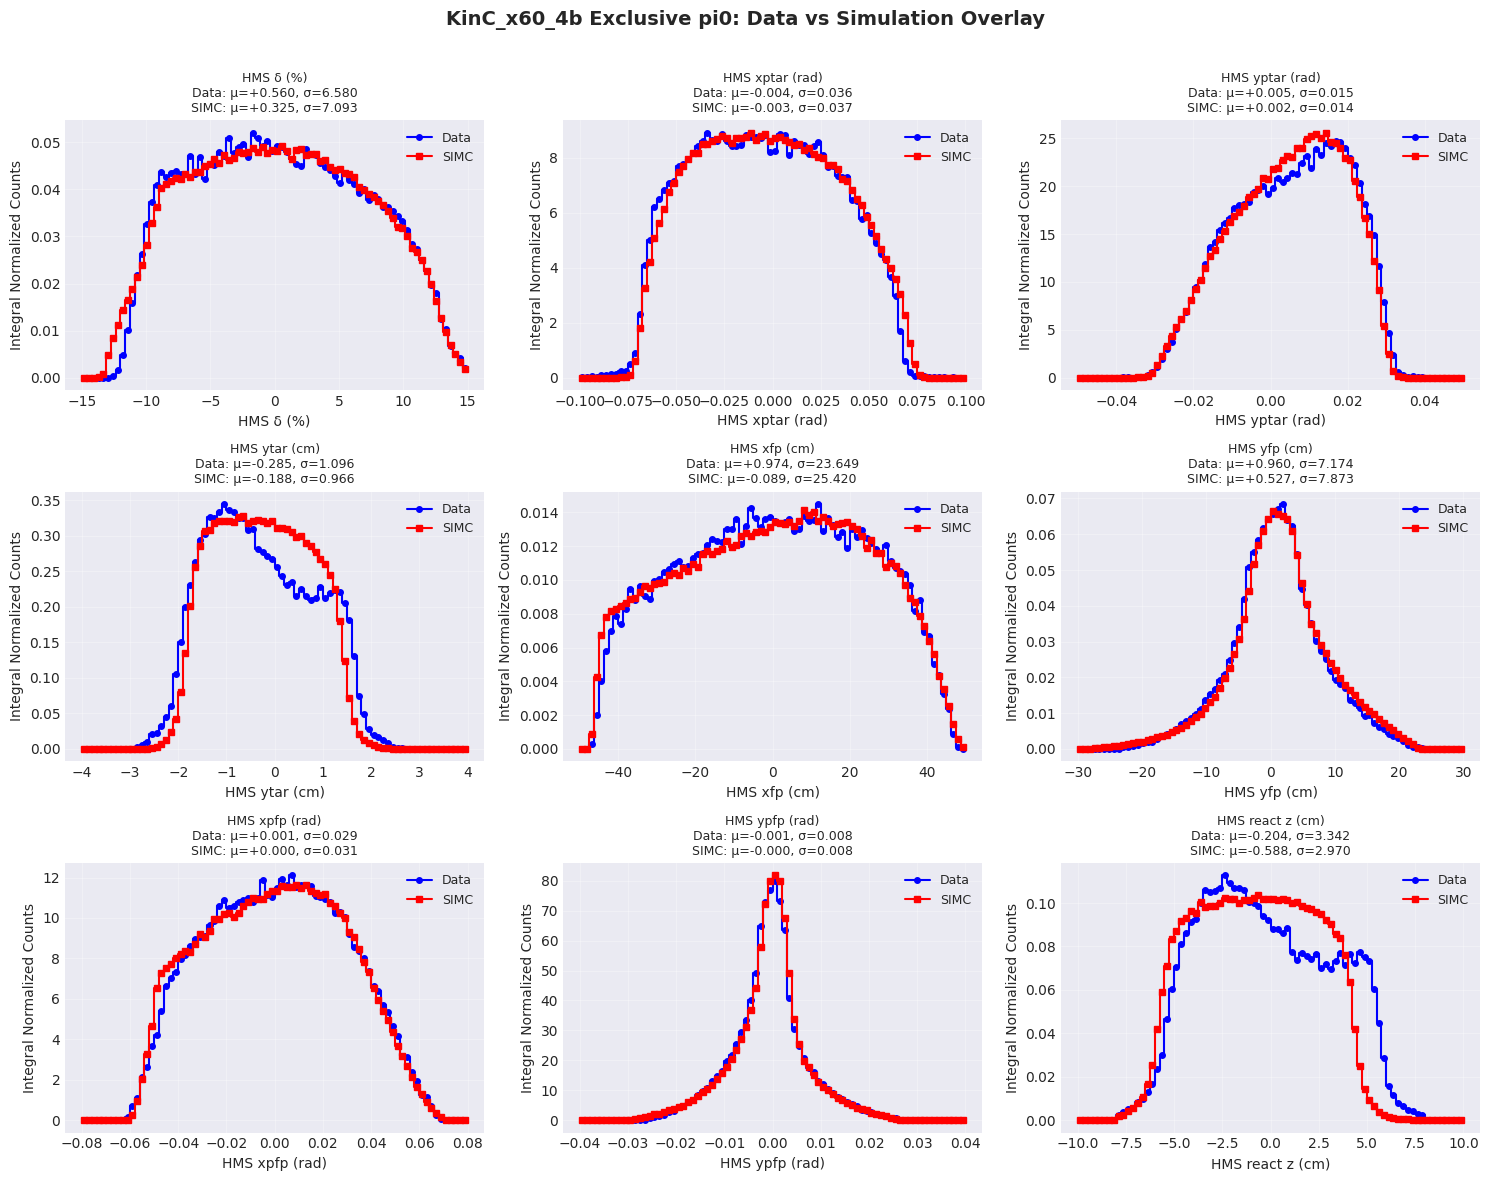

In [111]:
# Section 7: Create Overlay Plots

print("\n" + "="*80)
print("GENERATING OVERLAY PLOTS")
print("="*80)

# Create multi-panel figure
n_vars = len(variables)
ncols = 3
nrows = int(np.ceil(n_vars / ncols))

fig, axs = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axs = axs.flatten()

for i, (var_name, (data_branch, simc_branch, x_range)) in enumerate(variables.items()):
    ax = axs[i]
    try:
        hist_info = histograms[var_name]
        # Extract histogram data
        hist_data = hist_info['data']
        hist_sim = hist_info['sim']
        bin_centers = hist_info['bin_centers']
        # Get statistics
        var_stats = stats_df[stats_df['Variable'] == var_name].iloc[0]
        data_mean = var_stats['Data_μ']
        data_std = var_stats['Data_σ']
        sim_mean = var_stats['Sim_μ']
        sim_std = var_stats['Sim_σ']
        # Plot as step histograms (original style)
        ax.plot(bin_centers, hist_data, drawstyle='steps-mid', color='blue', marker='o', markersize=4, label='Data', linewidth=1.5)
        ax.plot(bin_centers, hist_sim, drawstyle='steps-mid', color='red', marker='s', markersize=4, label='SIMC', linewidth=1.5)
        # Set limits and labels
        ax.set_ylabel("Integral Normalized Counts", fontsize=10)
        ax.set_xlabel(var_name, fontsize=10)
        # Create title with statistics
        title = f"{var_name}\n"
        title += f"Data: μ={data_mean:+.3f}, σ={data_std:.3f}\n"
        title += f"SIMC: μ={sim_mean:+.3f}, σ={sim_std:.3f}"
        ax.set_title(title, fontsize=9)
        # Enable grid
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=9)
    except Exception as e:
        ax.text(0.5, 0.5, f"Error: {var_name}\n{e}", ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')

# Turn off unused subplots
for j in range(len(variables), len(axs)):
    axs[j].axis('off')

# Set main title
fig.suptitle("KinC_x60_4b Exclusive pi0: Data vs Simulation Overlay", fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.97])

# Save figure
plot_file = os.path.join(output_dir, "overlay_all_variables.png")
plt.savefig(plot_file, dpi=150, bbox_inches='tight')
print(f"\n✓ Overlay plot saved: {plot_file}")

plt.show()



GENERATING HREACTZ DISTRIBUTION PLOT

✓ hreactz distribution plot saved: ./production_diagnostics/hreactz_distribution.png


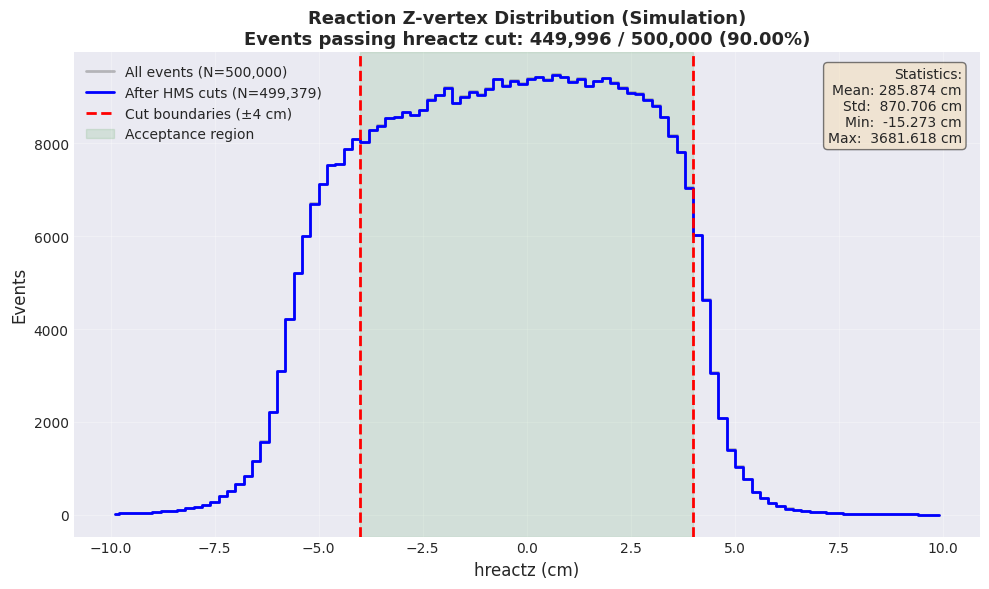

In [112]:
# Section 7.5: Plot hreactz Distribution (Simulation Only)

print("\n" + "="*80)
print("GENERATING HREACTZ DISTRIBUTION PLOT")
print("="*80)

# Create figure for hreactz
fig, ax = plt.subplots(figsize=(10, 6))

# Get hreactz values
hreactz_all = simc_arrs['hreactz']
hreactz_hms = hreactz_all[hms_electron_cuts(simc_arrs, is_data=False)]

# Define histogram range
hreactz_range = (-10, 10)
bins = 100

# Plot histograms
hist_all, bin_edges_all = np.histogram(hreactz_all, bins=bins, range=hreactz_range)
hist_hms, _ = np.histogram(hreactz_hms, bins=bins, range=hreactz_range)

bin_centers = 0.5 * (bin_edges_all[:-1] + bin_edges_all[1:])

# Plot as step histograms
ax.plot(bin_centers, hist_all, drawstyle='steps-mid', color='gray', 
        alpha=0.5, label=f'All events (N={len(hreactz_all):,})', linewidth=2)
ax.plot(bin_centers, hist_hms, drawstyle='steps-mid', color='blue', 
        label=f'After HMS cuts (N={len(hreactz_hms):,})', linewidth=2)

# Add vertical lines for cut boundaries
ax.axvline(-4.0, color='red', linestyle='--', linewidth=2, label='Cut boundaries (±4 cm)')
ax.axvline(4.0, color='red', linestyle='--', linewidth=2)

# Shade the acceptance region
ax.axvspan(-4.0, 4.0, alpha=0.1, color='green', label='Acceptance region')

# Labels and title
ax.set_xlabel('hreactz (cm)', fontsize=12)
ax.set_ylabel('Events', fontsize=12)
ax.set_title('Reaction Z-vertex Distribution (Simulation)\n' + 
             f'Events passing hreactz cut: {mask_hreactz.sum():,} / {len(hreactz_all):,} ' +
             f'({100*mask_hreactz.sum()/len(hreactz_all):.2f}%)', 
             fontsize=13, fontweight='bold')

# Add statistics text box
stats_text = f'Statistics:\n'
stats_text += f'Mean: {np.mean(hreactz_all):.3f} cm\n'
stats_text += f'Std:  {np.std(hreactz_all):.3f} cm\n'
stats_text += f'Min:  {np.min(hreactz_all):.3f} cm\n'
stats_text += f'Max:  {np.max(hreactz_all):.3f} cm'

ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()

# Save figure
hreactz_plot_file = os.path.join(output_dir, "hreactz_distribution.png")
plt.savefig(hreactz_plot_file, dpi=150, bbox_inches='tight')
print(f"\n✓ hreactz distribution plot saved: {hreactz_plot_file}")

plt.show()

print("="*80)


In [113]:
# Section 8: Generate Summary Statistics and Goodness-of-Fit Analysis

print("\n" + "="*80)
print("SUMMARY STATISTICS AND GOODNESS-OF-FIT ANALYSIS")
print("="*80)

# Display statistics table
print("\n" + "="*80)
print("Variable Comparison Statistics")
print("="*80)
print(stats_df.to_string(index=False))

# Save statistics to CSV
csv_file = os.path.join(output_dir, "summary_statistics.csv")
stats_df.to_csv(csv_file, index=False)
print(f"\n✓ Statistics saved: {csv_file}")

# Print cut efficiency summary
print("\n" + "="*80)
print("Event Selection Efficiency")
print("="*80)
print(f"\nData ({os.path.basename(DATA_FILE)}):")
print(f"  Total events:       {n_data_total:,}")
print(f"  Events passing cuts: {n_data_pass:,}")
print(f"  Selection efficiency: {100*n_data_pass/n_data_total:.2f}%")

print(f"\nSimulation ({os.path.basename(SIM_FILE)}):")
print(f"  Total events:       {n_simc_total:,}")
print(f"  Events passing cuts: {n_simc_pass:,}")
print(f"  Selection efficiency: {100*n_simc_pass/n_simc_total:.2f}%")

# Goodness-of-fit interpretation
print("\n" + "="*80)
print("Goodness-of-Fit Interpretation")
print("="*80)
print("\nInterpretation: Chi2 metric < 1.0 and Mean diff < 5% indicate good agreement")

good_chi2 = stats_df[stats_df['Chi2_metric'] < 1.0]
good_mean = stats_df[stats_df['Mean_diff_%'] < 5.0]
excellent = stats_df[(stats_df['Chi2_metric'] < 1.0) & (stats_df['Mean_diff_%'] < 5.0)]

print(f"\n✓ Excellent Agreement (Chi2 < 1.0 AND Mean diff < 5%): {len(excellent)} variables")
for _, row in excellent.iterrows():
    print(f"  • {row['Variable']:20s} Chi2={row['Chi2_metric']:.3f}, Mean diff={row['Mean_diff_%']:.2f}%")

if len(excellent) < len(variables):
    moderate = stats_df[~((stats_df['Chi2_metric'] < 1.0) & (stats_df['Mean_diff_%'] < 5.0))]
    print(f"\n⚠ Moderate Agreement: {len(moderate)} variables")
    for _, row in moderate.iterrows():
        print(f"  • {row['Variable']:20s} Chi2={row['Chi2_metric']:.3f}, Mean diff={row['Mean_diff_%']:.2f}%")
else:
    print(f"\n✓ All variables show excellent agreement!")

print("\n" + "="*80)



SUMMARY STATISTICS AND GOODNESS-OF-FIT ANALYSIS

Variable Comparison Statistics
        Variable    Data_μ    Data_σ  Data_median     Sim_μ     Sim_σ  Sim_median        Δμ        Δσ  Chi2_metric  Mean_diff_%
       HMS δ (%)  0.560154  6.580300     0.356616  0.324553  7.093410    0.040732  0.235601 -0.513110     0.060350    42.060042
 HMS xptar (rad) -0.004394  0.035819    -0.005177 -0.003219  0.037015   -0.004772 -0.001175 -0.001196     9.160622    26.746957
 HMS yptar (rad)  0.005096  0.014552     0.006332  0.001919  0.014344    0.002344  0.003177  0.000208    10.853479    62.334849
   HMS ytar (cm) -0.284945  1.095950    -0.401455 -0.187904  0.965896   -0.189502 -0.097041  0.130054     0.995350    34.056135
    HMS xfp (cm)  0.973911 23.649070     1.596888 -0.088832 25.420403    0.535140  1.062743 -1.771332     0.007933   109.121177
    HMS yfp (cm)  0.959829  7.173703     0.916112  0.526712  7.873317    0.608945  0.433117 -0.699614     0.021805    45.124372
  HMS xpfp (rad)  0.001

In [114]:
# Section 9: Inspect combined_diagnostics_LH2.npz file

print("\n" + "="*80)
print("INSPECTING COMBINED_DIAGNOSTICS_LH2.NPZ FILE")
print("="*80)

# Path to the .npz file
npz_file = "/w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env/combined_diagnostics_LH2.npz"

try:
    # Load the .npz file
    with np.load(npz_file, allow_pickle=True) as data:
        print(f"\n✓ File loaded: {npz_file}")
        print(f"\nArrays contained in the file:")
        print("="*80)
        
        # List all arrays in the file
        for key in data.files:
            arr = data[key]
            print(f"\n  {key}:")
            print(f"    Shape: {arr.shape}")
            print(f"    Dtype: {arr.dtype}")
            
            # Show some statistics for numeric arrays
            if np.issubdtype(arr.dtype, np.number):
                if arr.size > 0:
                    print(f"    Min:   {np.min(arr):.6g}")
                    print(f"    Max:   {np.max(arr):.6g}")
                    print(f"    Mean:  {np.mean(arr):.6g}")
                    print(f"    Std:   {np.std(arr):.6g}")
            else:
                # For non-numeric arrays, just show first few elements
                if arr.size > 0:
                    print(f"    First element(s): {arr.flat[0] if arr.size == 1 else arr.flatten()[:3]}")
        
        print("\n" + "="*80)
        
except FileNotFoundError:
    print(f"\n✗ Error: File '{npz_file}' not found")
    print(f"   Please provide the correct path to the file")
    
except Exception as e:
    print(f"\n✗ Error loading file: {e}")


INSPECTING COMBINED_DIAGNOSTICS_LH2.NPZ FILE

✗ Error: File '/w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env/combined_diagnostics_LH2.npz' not found
   Please provide the correct path to the file
